# Q-learning 강화학습 실습 — 택시 게임 (Taxi)

**택시 게임**은 강화학습의 대표 예제입니다. 노란 택시가 격자 도시를 돌아다니며 **손님을 태우고(pickup) 목적지에 내려주는(dropoff)** 것이 목표입니다.

- **상태(state)**: 택시 위치(25칸) × 손님 위치(5) × 목적지(4) = **500가지**
- **행동(action)**: 상(0)·하(1)·우(2)·좌(3)·태우기(4)·내리기(5) = **6가지**
- **보상(reward)**: 한 스텝마다 −1, 잘못 태우기/내리기 −10, 성공적으로 내려주면 **+20**

택시는 처음엔 아무것도 모르지만, **Q-table** 에 "어떤 상태에서 어떤 행동이 좋은지"를 시행착오로 채워가며 똑똑해집니다.

## 목차
1. 라이브러리 임포트 & 환경 살펴보기
2. Q-table 과 하이퍼파라미터 설정
3. Q-learning 학습
4. 학습 곡선 시각화
5. 학습된 택시 운행 장면 보기
6. 학습 전 vs 후 성능 비교

## 1. 라이브러리 임포트 & 환경 살펴보기

`gymnasium` 의 `Taxi-v4` 환경을 사용합니다. `render_mode='ansi'` 로 만들면 게임 화면을 텍스트로 출력할 수 있습니다.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym

# 그래프 한글 깨짐 방지 (Ubuntu: NanumGothic)
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

np.random.seed(0)

env = gym.make('Taxi-v4', render_mode='ansi')
print('상태 개수:', env.observation_space.n)
print('행동 개수:', env.action_space.n)

# 게임 화면 한 장면 출력
state, info = env.reset(seed=42)
print('\n현재 화면 (R/G/Y/B는 손님/목적지 위치):')
print(env.render())

상태 개수: 500
행동 개수: 6

현재 화면 (R/G/Y/B는 손님/목적지 위치):
+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+




화면 설명:
- 노란 네모(또는 색칠된 칸)가 **택시**, 손님을 태우면 색이 바뀝니다.
- `R G Y B` 네 글자는 손님이 기다리는 곳/목적지 후보입니다.
- `|` 는 택시가 통과할 수 없는 **벽**입니다.

## 2. Q-table 과 하이퍼파라미터 설정

**Q-table** 은 `(상태 500 × 행동 6)` 크기의 표로, 각 칸은 "이 상태에서 이 행동을 했을 때 기대되는 미래 보상"을 뜻합니다. 처음엔 모두 0(아무것도 모름)으로 시작합니다.

In [10]:
Q = np.zeros((env.observation_space.n, env.action_space.n))

alpha = 0.1       # 학습률: 새 정보를 얼마나 반영할지
gamma = 0.99      # 할인율: 미래 보상을 얼마나 중요하게 볼지
epsilon = 1.0     # 탐험 비율: 처음엔 100% 무작위 행동
epsilon_min = 0.01
epsilon_decay = 0.9995

EPISODES = 15000  # 한 판(에피소드)을 몇 번 반복할지

print('Q-table 크기:', Q.shape)

Q-table 크기: (500, 6)


## 3. Q-learning 학습

핵심은 **Q-learning 업데이트 식** 하나입니다:

$$Q(s,a) \leftarrow Q(s,a) + \alpha \left[ r + \gamma \max_{a'} Q(s',a') - Q(s,a) \right]$$

- **ε-greedy 탐험**: 확률 ε 로 무작위 행동(탐험), 나머지는 Q값이 가장 큰 행동(활용)을 선택합니다.
- 학습이 진행될수록 ε 를 줄여 무작위성을 낮추고 똑똑한 선택을 늘립니다.

> 15000판 학습은 보통 십여 초면 끝납니다.

In [ ]:
rewards_history = []

for episode in range(EPISODES):
    state, _ = env.reset(seed=episode)
    done = False
    total_reward = 0

    while not done:
        # ε-greedy 행동 선택
        if np.random.rand() < epsilon:
            action = env.action_space.sample()   # 탐험
        else:
            action = int(np.argmax(Q[state]))     # 활용

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Q-learning 업데이트
        best_next = np.max(Q[next_state])
        Q[state, action] += alpha * (reward + gamma * best_next - Q[state, action])

        state = next_state
        total_reward += reward

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards_history.append(total_reward)

    if (episode + 1) % 1500 == 0:
        avg = np.mean(rewards_history[-1500:])
        print(f'에피소드 {episode+1:5d}/{EPISODES}  최근 평균보상: {avg:6.1f}  ε={epsilon:.3f}')

print('\n학습 완료!')

## 4. 학습 곡선 시각화

에피소드별 총 보상이 −700 부근(헤매는 택시)에서 +8 부근(최적 운행)으로 올라가는 과정을 봅니다. 들쭉날쭉하므로 100판 이동평균으로 부드럽게 그립니다.

In [ ]:
rewards = np.array(rewards_history)
window = 100
moving_avg = np.convolve(rewards, np.ones(window) / window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(moving_avg)
plt.title('학습 곡선: 에피소드별 총 보상 (100판 이동평균)')
plt.xlabel('에피소드')
plt.ylabel('총 보상')
plt.grid(True, alpha=0.3)
plt.show()

## 5. 학습된 택시 운행 장면 보기

이제 ε=0(무작위 없이 학습한 Q-table 만 사용)으로 한 판을 실행하며, 택시가 손님을 태우고 목적지로 가는 장면을 단계별로 출력합니다.

In [ ]:
state, _ = env.reset(seed=123)
done = False
step = 0
frames = []
action_names = ['남(아래)', '북(위)', '동(오른)', '서(왼)', '태우기', '내리기']

while not done and step < 30:
    frames.append(env.render())
    action = int(np.argmax(Q[state]))
    state, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    step += 1
    print(f'스텝 {step:2d} | 행동: {action_names[action]:8s} | 보상: {reward:+d}')
frames.append(env.render())

print(f'\n총 {step}스텝 만에 목적지 도착! 🚕')
print('\n[마지막 장면]')
print(frames[-1])

원하면 아래처럼 첫 장면부터 순서대로 모든 프레임을 출력해 택시의 이동 경로를 눈으로 따라갈 수 있습니다.

In [ ]:
for i, f in enumerate(frames):
    print(f'===== 프레임 {i} =====')
    print(f)

## 6. 학습 전 vs 후 성능 비교

무작위로 움직이는 택시(학습 전)와 Q-table 을 따르는 택시(학습 후)를 각각 100판 돌려 평균 성능을 비교합니다.

In [ ]:
def run_policy(use_q, n=100):
    total_rewards, total_steps = [], []
    for ep in range(n):
        state, _ = env.reset(seed=90000 + ep)
        done, r_sum, s = False, 0, 0
        while not done and s < 200:
            action = int(np.argmax(Q[state])) if use_q else env.action_space.sample()
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            r_sum += reward; s += 1
        total_rewards.append(r_sum); total_steps.append(s)
    return np.mean(total_rewards), np.mean(total_steps)

r_before, s_before = run_policy(use_q=False)
r_after,  s_after  = run_policy(use_q=True)

print(f'학습 전(무작위): 평균보상 {r_before:7.1f} | 평균스텝 {s_before:5.1f}')
print(f'학습 후(Q-learning): 평균보상 {r_after:7.1f} | 평균스텝 {s_after:5.1f}')

## 7. 학습된 정책 전체 지도 그리기

택시가 학습한 **Q-table** 을 지도로 펼쳐 봅니다. (손님 위치, 목적지)를 하나 고정하면, 택시가 있을 수 있는 **25칸 각각에서 어떤 행동이 최선인지**를 화살표로 그릴 수 있습니다.

- **화살표** → 그 칸에서 이동할 최선 방향
- **P / D** → 그 칸에서는 태우기(Pickup) / 내리기(Dropoff) 가 최선

아래 두 지도를 보면, ① 손님을 태우기 전에는 화살표가 모두 **손님(R)** 쪽으로 모이고, ② 손님을 태운 뒤에는 모두 **목적지(G)** 쪽으로 모이는 걸 확인할 수 있습니다. 택시가 "길찾기"를 스스로 배운 셈입니다.

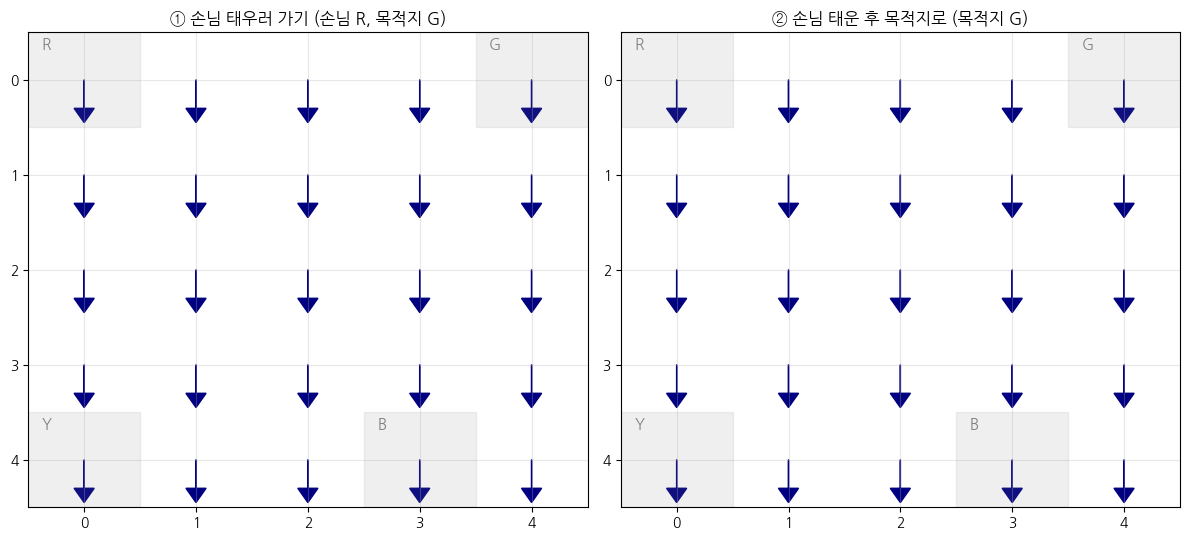

In [11]:
# 행동 -> 화살표 방향 (dcol, drow). 0:남(아래) 1:북(위) 2:동(오른) 3:서(왼)
MOVE = {0: (0, 1), 1: (0, -1), 2: (1, 0), 3: (-1, 0)}
LOC = {0: (0, 0), 1: (0, 4), 2: (4, 0), 3: (4, 3)}   # R, G, Y, B 위치 (row, col)
LOC_NAME = ['R', 'G', 'Y', 'B']

def plot_policy_map(pass_loc, dest, ax, title):
    """고정된 (손님 위치, 목적지)에서 25개 택시 칸마다 학습된 최선 행동을 그림."""
    for r in range(5):
        for c in range(5):
            s = env.unwrapped.encode(r, c, pass_loc, dest)
            action = int(np.argmax(Q[s]))
            if action in MOVE:                       # 이동 행동 -> 화살표
                dc, dr = MOVE[action]
                ax.arrow(c, r, dc * 0.3, dr * 0.3,
                         head_width=0.18, head_length=0.15, fc='navy', ec='navy')
            else:                                    # 4:태우기(P) / 5:내리기(D)
                ax.text(c, r, 'P' if action == 4 else 'D', ha='center', va='center',
                        fontsize=18, fontweight='bold', color='crimson')
    for i, (lr, lc) in LOC.items():                  # R/G/Y/B 위치 음영 표시
        ax.add_patch(plt.Rectangle((lc - 0.5, lr - 0.5), 1, 1, alpha=0.12, color='gray'))
        ax.text(lc - 0.38, lr - 0.32, LOC_NAME[i], fontsize=11, color='gray')
    ax.set_xticks(range(5)); ax.set_yticks(range(5))
    ax.set_xlim(-0.5, 4.5); ax.set_ylim(-0.5, 4.5)
    ax.invert_yaxis()                                # row 0 을 맨 위로
    ax.grid(True, alpha=0.3)
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
plot_policy_map(0, 1, axes[0], '① 손님 태우러 가기 (손님 R, 목적지 G)')
plot_policy_map(4, 1, axes[1], '② 손님 태운 후 목적지로 (목적지 G)')
plt.tight_layout()
plt.show()

## 정리

- **Q-learning** 은 `(상태 × 행동)` 표에 "각 상황에서 어떤 행동이 좋은지"를 시행착오로 채워가는 알고리즘입니다.
- 핵심은 업데이트 식 한 줄: `Q[s,a] += α(r + γ·max Q[s'] − Q[s,a])`.
- **ε-greedy** 로 초반엔 많이 탐험하고 점점 학습한 지식을 활용하도록 했습니다.
- 무작위로 −700점씩 헤매던 택시가 +8점으로 손님을 척척 실어 나르게 됩니다. 🚕
- 더 해보기: `alpha`, `gamma`, `epsilon_decay` 를 바꿔 학습 속도 비교 / 같은 방식으로 **FrozenLake**, **CliffWalking** 도전 / 상태가 많아지면 Q-table 대신 신경망을 쓰는 **DQN** 으로 확장.